In [1]:
# We start by importing all the libraries we need for this project
# pandas and numpy are for data handling
# matplotlib and seaborn are for making charts
# sklearn has all the machine learning tools we need

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# importing the models we will be testing
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# importing tools for preprocessing and evaluation
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score

# loading the dataset files into dataframes
# the main file has patient symptoms and diseases
# the other 3 files give us extra info about symptoms
df = pd.read_csv("dataset.csv")
severity_df = pd.read_csv("Symptom-severity.csv")
description_df = pd.read_csv("symptom_description.csv")
precaution_df = pd.read_csv("symptom_precaution.csv")

print("files loaded successfully")
print("main dataset shape:", df.shape)
print("severity file shape:", severity_df.shape)
print("description file shape:", description_df.shape)
print("precaution file shape:", precaution_df.shape)

files loaded successfully
main dataset shape: (4920, 18)
severity file shape: (133, 2)
description file shape: (41, 2)
precaution file shape: (41, 5)


In [2]:
# first lets get a basic understanding of what the data looks like
# how many rows, columns, diseases and what the data types are

print("basic info about the dataset")
print("rows:", df.shape[0])
print("columns:", df.shape[1])
print("unique diseases:", df['Disease'].nunique())
print("number of symptom columns:", df.shape[1] - 1)

print("\nfirst 5 rows of the dataset:")
display(df.head())

print("\ndata types of each column:")
print(df.dtypes)

# checking for missing values - we noticed symptoms have a lot of NaN
# this is not actually an error, it just means the patient had fewer symptoms
print("\nmissing values in each column:")
print(df.isnull().sum())

# checking if classes are balanced - important for machine learning
print("\nhow many records per disease:")
print(df['Disease'].value_counts())

basic info about the dataset
rows: 4920
columns: 18
unique diseases: 41
number of symptom columns: 17

first 5 rows of the dataset:


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



data types of each column:
Disease       object
Symptom_1     object
Symptom_2     object
Symptom_3     object
Symptom_4     object
Symptom_5     object
Symptom_6     object
Symptom_7     object
Symptom_8     object
Symptom_9     object
Symptom_10    object
Symptom_11    object
Symptom_12    object
Symptom_13    object
Symptom_14    object
Symptom_15    object
Symptom_16    object
Symptom_17    object
dtype: object

missing values in each column:
Disease          0
Symptom_1        0
Symptom_2        0
Symptom_3        0
Symptom_4      348
Symptom_5     1206
Symptom_6     1986
Symptom_7     2652
Symptom_8     2976
Symptom_9     3228
Symptom_10    3408
Symptom_11    3726
Symptom_12    4176
Symptom_13    4416
Symptom_14    4614
Symptom_15    4680
Symptom_16    4728
Symptom_17    4848
dtype: int64

how many records per disease:
Disease
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic chole

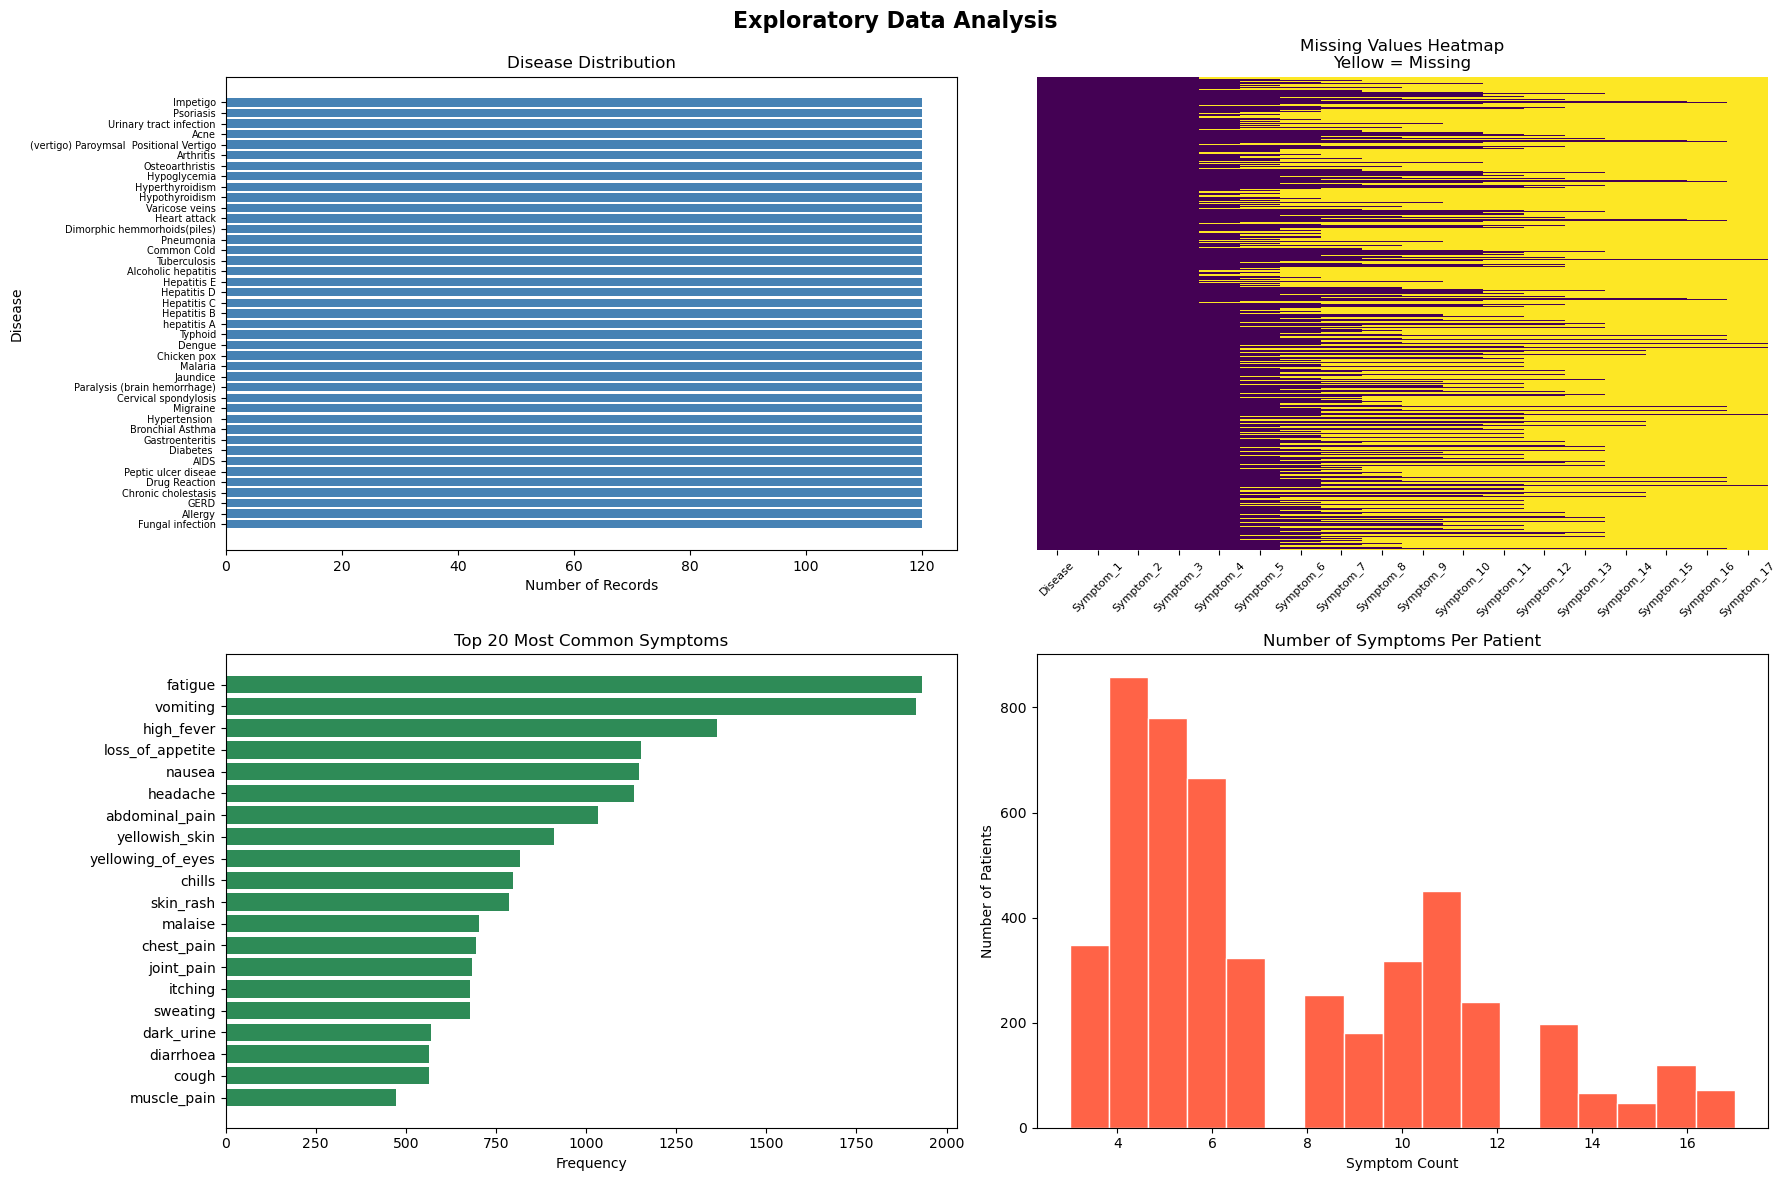

observations from EDA:
1. all diseases have exactly 120 records - perfectly balanced
2. missing values increase after symptom 4 - not an error
3. fatigue and vomiting appear in almost all diseases
4. most patients report between 3 to 5 symptoms
5. all columns are text type - need to convert to numbers


In [3]:
# now we will plot some charts to better understand the data
# we made 4 charts - disease distribution, missing values,
# top symptoms and how many symptoms each patient has

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Exploratory Data Analysis", fontsize=16, fontweight='bold')

# chart 1 - how many records does each disease have
# we want to check if the classes are balanced or not
disease_counts = df['Disease'].value_counts()
axes[0,0].barh(disease_counts.index, disease_counts.values, color='steelblue')
axes[0,0].set_title("Disease Distribution")
axes[0,0].set_xlabel("Number of Records")
axes[0,0].set_ylabel("Disease")
axes[0,0].tick_params(axis='y', labelsize=7)

# chart 2 - heatmap to visualize where missing values are
# yellow means missing, purple means data is present
# we can clearly see data gets sparser after symptom 4
sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0,1])
axes[0,1].set_title("Missing Values Heatmap\nYellow = Missing")
axes[0,1].tick_params(axis='x', rotation=45, labelsize=8)

# chart 3 - which symptoms appear most often across all diseases
# we collect all symptom values from all 17 columns
symptom_cols = [col for col in df.columns if col != 'Disease']
all_syms = pd.Series(df[symptom_cols].values.flatten()).dropna().str.strip()
all_syms = all_syms[all_syms != '']
top20 = all_syms.value_counts().head(20)

axes[1,0].barh(top20.index, top20.values, color='seagreen')
axes[1,0].set_title("Top 20 Most Common Symptoms")
axes[1,0].set_xlabel("Frequency")
axes[1,0].invert_yaxis()

# chart 4 - how many symptoms does each patient report
# most patients report only 3 to 5 symptoms
symptom_count = df[symptom_cols].notna().sum(axis=1)
axes[1,1].hist(symptom_count, bins=17, color='tomato', edgecolor='white')
axes[1,1].set_title("Number of Symptoms Per Patient")
axes[1,1].set_xlabel("Symptom Count")
axes[1,1].set_ylabel("Number of Patients")

plt.tight_layout()
plt.show()

# some observations we noticed from the charts
print("observations from EDA:")
print("1. all diseases have exactly 120 records - perfectly balanced")
print("2. missing values increase after symptom 4 - not an error")
print("3. fatigue and vomiting appear in almost all diseases")
print("4. most patients report between 3 to 5 symptoms")
print("5. all columns are text type - need to convert to numbers")

Segment 1 ^

In [4]:
# before we can train any model we need to convert the data
# right now symptoms are stored as text in 17 separate columns
# we need to convert this into a binary matrix
# where each column is a symptom and value is 1 if present 0 if not

# step 1 - clean up the symptom text
# there are extra spaces in some symptom names so we strip them
df_clean = df.copy()
for col in symptom_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.replace(' ', '_')
    df_clean[col] = df_clean[col].replace('nan', np.nan)

# step 2 - get a list of all unique symptom names
all_symptom_names = sorted(set(
    pd.Series(df_clean[symptom_cols].values.flatten()).dropna().tolist()
))
print("total unique symptoms found:", len(all_symptom_names))

# step 3 - build the binary matrix
# for each patient we check which symptoms they have
# if they have the symptom we put 1 otherwise 0
X_clean = pd.DataFrame(0, index=df_clean.index, columns=all_symptom_names)
for col in symptom_cols:
    for symptom in all_symptom_names:
        X_clean.loc[df_clean[col] == symptom, symptom] = 1

# step 4 - convert disease names to numbers
# machine learning models need numbers not text
# so Fungal infection becomes 0, Allergy becomes 1 etc
le = LabelEncoder()
y = le.fit_transform(df_clean['Disease'].str.strip())

# step 5 - split data into training and testing sets
# 80% of data is used to train the model
# 20% is kept aside to test how well the model learned
# stratify makes sure each disease is equally represented in both sets
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

print("\npreprocessing done!")
print("training samples:", X_train_clean.shape[0])
print("testing samples:", X_test_clean.shape[0])
print("total features:", X_train_clean.shape[1])
print("total classes:", len(le.classes_))
print("\nsample of binary matrix:")
display(X_clean.iloc[:3, :8])

total unique symptoms found: 131

preprocessing done!
training samples: 3936
testing samples: 984
total features: 131
total classes: 41

sample of binary matrix:


,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain
0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0


In [5]:
# now we train all 5 models on the clean data
# we also need to scale the data for SVM and MLP
# scaling means converting all values to a similar range
# SVM and MLP are sensitive to the scale of input features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

# training all 5 models one by one
# each model learns patterns from the training data
# then we check accuracy on the test data it has never seen

# model 1 - decision tree
# works like a flowchart of yes/no questions
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_clean, y_train_clean)
dt_acc = accuracy_score(y_test_clean, dt.predict(X_test_clean))
print("Decision Tree accuracy:", round(dt_acc * 100, 2), "%")

# model 2 - random forest
# builds 100 decision trees and takes majority vote
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_clean, y_train_clean)
rf_acc = accuracy_score(y_test_clean, rf.predict(X_test_clean))
print("Random Forest accuracy:", round(rf_acc * 100, 2), "%")

# model 3 - svm
# finds the best boundary line to separate classes
# needs scaled data to work properly
svm = SVC(kernel='rbf', random_state=42, probability=True)
svm.fit(X_train_scaled, y_train_clean)
svm_acc = accuracy_score(y_test_clean, svm.predict(X_test_scaled))
print("SVM accuracy:", round(svm_acc * 100, 2), "%")

# model 4 - xgboost
# builds trees one after another each fixing mistakes of previous
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='mlogloss', verbosity=0)
xgb.fit(X_train_clean, y_train_clean)
xgb_acc = accuracy_score(y_test_clean, xgb.predict(X_test_clean))
print("XGBoost accuracy:", round(xgb_acc * 100, 2), "%")

# model 5 - mlp neural network
# loosely inspired by how the brain works
# has layers of connected nodes that learn patterns
# also needs scaled data like svm
mlp = MLPClassifier(hidden_layer_sizes=(256, 128, 64),
                    activation='relu', max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train_clean)
mlp_acc = accuracy_score(y_test_clean, mlp.predict(X_test_scaled))
print("MLP accuracy:", round(mlp_acc * 100, 2), "%")

print("\nall models give 100% - something is wrong here")

Decision Tree accuracy: 100.0 %
Random Forest accuracy: 100.0 %
SVM accuracy: 100.0 %
XGBoost accuracy: 100.0 %
MLP accuracy: 100.0 %

all models give 100% - something is wrong here


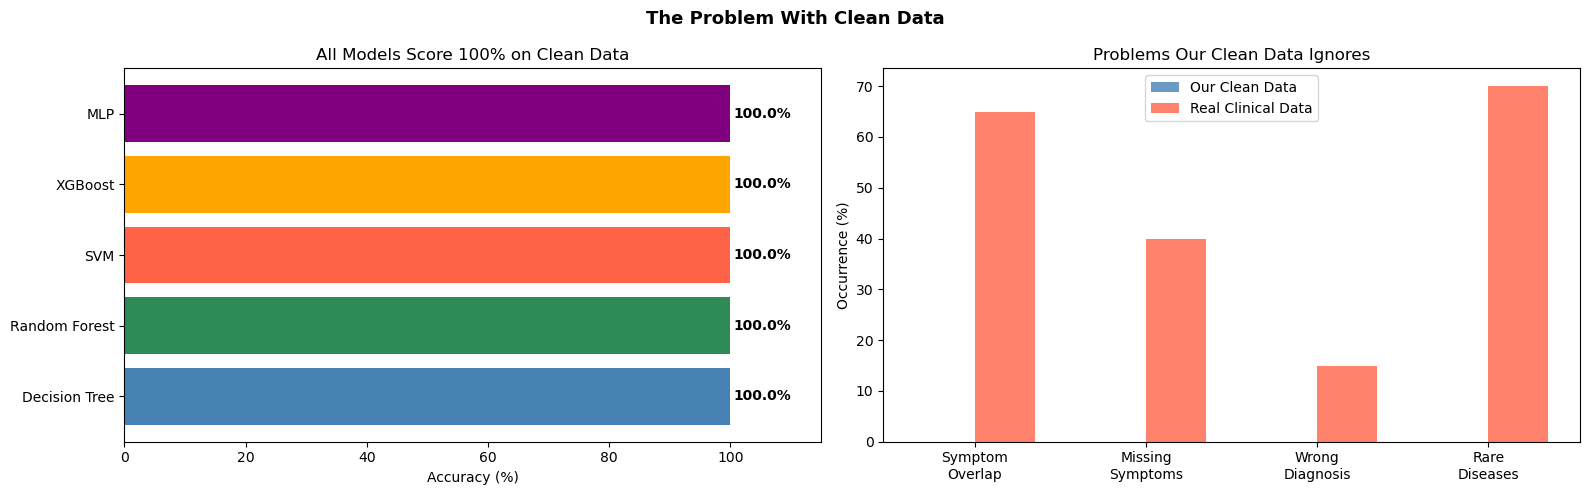

In [6]:
# lets visualise this problem clearly
# left chart shows all models at 100%
# right chart shows what real clinical data looks like vs our clean data
# this helps us explain why we need to add noise

clean_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'SVM', 'XGBoost', 'MLP'],
    'Accuracy': [dt_acc*100, rf_acc*100, svm_acc*100, xgb_acc*100, mlp_acc*100]
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("The Problem With Clean Data", fontsize=13, fontweight='bold')

# left - all models scoring 100%
colors = ['steelblue', 'seagreen', 'tomato', 'orange', 'purple']
bars = axes[0].barh(clean_results['Model'],
                    clean_results['Accuracy'], color=colors)
axes[0].set_xlim(0, 115)
axes[0].set_title("All Models Score 100% on Clean Data")
axes[0].set_xlabel("Accuracy (%)")
for bar, val in zip(bars, clean_results['Accuracy']):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontweight='bold')

# right - real world problems our data doesnt have
problems = ['Symptom\nOverlap', 'Missing\nSymptoms',
            'Wrong\nDiagnosis', 'Rare\nDiseases']
clean_world = [0, 0, 0, 0]
real_world = [65, 40, 15, 70]

x = np.arange(len(problems))
w = 0.35
axes[1].bar(x - w/2, clean_world, w, label='Our Clean Data', color='steelblue', alpha=0.8)
axes[1].bar(x + w/2, real_world, w, label='Real Clinical Data', color='tomato', alpha=0.8)
axes[1].set_title("Problems Our Clean Data Ignores")
axes[1].set_ylabel("Occurrence (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(problems)
axes[1].legend()

plt.tight_layout()
plt.show()

## Why 100% Accuracy Is A Problem

When we trained all 5 models on the clean dataset every single
model scored 100% accuracy. This looks great at first but it is
actually a serious problem for the following reasons:

### Reason 1 - The Dataset Is Synthetic
The data was artificially created with exact fixed symptom sets
for each disease. Real patients do not present symptoms this
perfectly.

### Reason 2 - No Symptom Overlap
In reality fatigue and fever could mean malaria, typhoid, dengue
or flu. Our clean data assigns each symptom combination to
exactly one disease with zero ambiguity.

### Reason 3 - We Cannot Compare Models
When everything scores 100% we have no way to tell which model
is actually better or more reliable on unseen data.

### Reason 4 - No Real Challenge
A machine learning project should show how we handle difficult
data. Clean perfect data removes all the interesting challenges.

### Our Solution
We will add 4 types of realistic noise to the dataset to
simulate what real clinical symptom data actually looks like.
This will make the project more meaningful and the model
comparison more useful.

Segment 2 ^

In [7]:
# the clean data gave us 100% which is unrealistic
# we now add 4 types of noise to simulate real world clinical data
# each type of noise represents something that happens in real hospitals

np.random.seed(42)
X_noisy = X_clean.copy()
y_noisy = y.copy()

n_samples, n_features = X_noisy.shape
n_diseases = len(le.classes_)

# noise type 1 - symptom dropout
# in real life patients forget to mention some symptoms
# or doctors miss recording them during consultation
# we randomly remove 20% of symptoms that were present
dropout_mask = (np.random.random(X_noisy.shape) < 0.20) & (X_noisy.values == 1)
X_noisy[dropout_mask] = 0
dropped = dropout_mask.sum().sum()
print("noise 1 - symptom dropout: removed", dropped, "symptom entries")

# noise type 2 - false positive symptoms
# patients sometimes report symptoms they dont actually have
# or symptoms get recorded incorrectly
# we randomly add 10% false symptoms
false_mask = (np.random.random(X_noisy.shape) < 0.10) & (X_noisy.values == 0)
X_noisy[false_mask] = 1
added = false_mask.sum().sum()
print("noise 2 - false symptoms: added", added, "false symptom entries")

# noise type 3 - class imbalance
# in real hospitals some diseases are much more common than others
# for example flu patients are far more common than rare diseases
# we randomly keep between 40% to 100% of records for each disease
keep_indices = []
np.random.seed(42)
for disease_id in range(n_diseases):
    indices = np.where(y_noisy == disease_id)[0]
    keep_ratio = np.random.uniform(0.40, 1.0)
    n_keep = max(15, int(len(indices) * keep_ratio))
    kept = np.random.choice(indices, n_keep, replace=False)
    keep_indices.extend(kept)

keep_indices = sorted(keep_indices)
X_noisy = X_noisy.iloc[keep_indices].reset_index(drop=True)
y_noisy = y_noisy[keep_indices]
print("noise 3 - class imbalance: removed", n_samples - len(keep_indices), "records")
print("remaining samples:", len(keep_indices))

# noise type 4 - label noise
# in real hospitals misdiagnosis happens
# a doctor might record the wrong disease for a patient
# we randomly flip 5% of disease labels to wrong ones
n_label_noise = int(len(y_noisy) * 0.05)
label_idx = np.random.choice(len(y_noisy), n_label_noise, replace=False)
for idx in label_idx:
    current = y_noisy[idx]
    wrong_labels = [d for d in range(n_diseases) if d != current]
    y_noisy[idx] = np.random.choice(wrong_labels)
print("noise 4 - label noise: mislabeled", n_label_noise, "records")

print("\nnoise added successfully")
print("original samples:", n_samples)
print("noisy samples:", len(X_noisy))

noise 1 - symptom dropout: removed 7223 symptom entries
noise 2 - false symptoms: added 61559 false symptom entries
noise 3 - class imbalance: removed 1570 records
remaining samples: 3350
noise 4 - label noise: mislabeled 167 records

noise added successfully
original samples: 4920
noisy samples: 3350


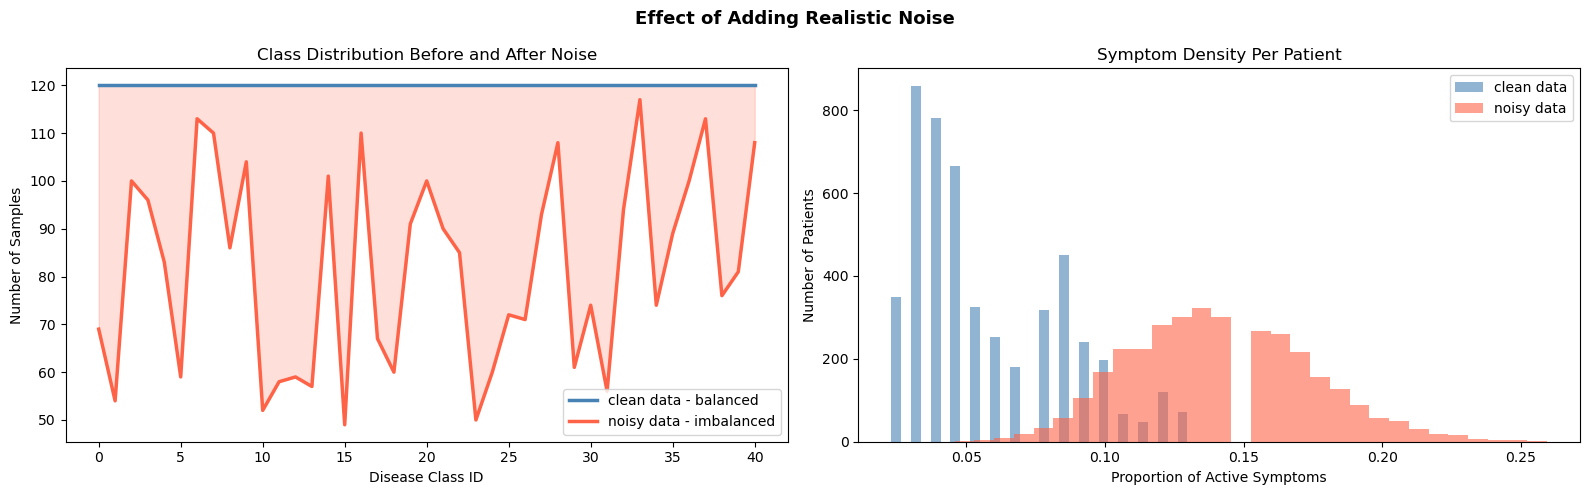

In [8]:
# lets visualise what the noise did to our dataset
# left chart shows class distribution before and after
# right chart shows how symptom density changed

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Effect of Adding Realistic Noise", fontsize=13, fontweight='bold')

# left - class distribution changed after noise
clean_counts = pd.Series(y).value_counts().sort_index()
noisy_counts = pd.Series(y_noisy).value_counts().sort_index()

axes[0].plot(clean_counts.values, label='clean data - balanced',
             color='steelblue', linewidth=2.5)
axes[0].plot(noisy_counts.values, label='noisy data - imbalanced',
             color='tomato', linewidth=2.5)
axes[0].fill_between(range(len(clean_counts)),
                     clean_counts.values, noisy_counts.values,
                     alpha=0.2, color='tomato')
axes[0].set_title("Class Distribution Before and After Noise")
axes[0].set_xlabel("Disease Class ID")
axes[0].set_ylabel("Number of Samples")
axes[0].legend()

# right - symptom density per patient changed
# clean data is tightly clustered
# noisy data is more spread out due to false symptoms
clean_density = X_clean.values.mean(axis=1)
noisy_density = X_noisy.values.mean(axis=1)

axes[1].hist(clean_density, bins=30, alpha=0.6,
             label='clean data', color='steelblue')
axes[1].hist(noisy_density, bins=30, alpha=0.6,
             label='noisy data', color='tomato')
axes[1].set_title("Symptom Density Per Patient")
axes[1].set_xlabel("Proportion of Active Symptoms")
axes[1].set_ylabel("Number of Patients")
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# splitting the noisy dataset into training and testing
# same 80/20 split as before
# stratify makes sure all diseases are represented in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X_noisy, y_noisy,
    test_size=0.2, random_state=42, stratify=y_noisy
)

# scaling for svm and mlp
scaler_noisy = StandardScaler()
X_train_scaled_n = scaler_noisy.fit_transform(X_train)
X_test_scaled_n = scaler_noisy.transform(X_test)

print("noisy dataset split done")
print("training samples:", X_train.shape[0])
print("testing samples:", X_test.shape[0])
print("features:", X_train.shape[1])
print("classes:", len(np.unique(y_noisy)))

# checking class balance after noise
counts = pd.Series(y_noisy).value_counts()
print("\nmost common disease has:", counts.max(), "samples")
print("rarest disease has:", counts.min(), "samples")
print("imbalance ratio:", round(counts.max() / counts.min(), 2), "x")

noisy dataset split done
training samples: 2680
testing samples: 670
features: 131
classes: 41

most common disease has: 117 samples
rarest disease has: 49 samples
imbalance ratio: 2.39 x


In [17]:
# now we retrain all 5 models but this time on the noisy data
# we expect the results to be much lower and different from each other
# this is more realistic and makes the comparison meaningful

print("training all 5 models on noisy data...")

# decision tree
dt_n = DecisionTreeClassifier(random_state=42)
dt_n.fit(X_train, y_train)
dt_n_acc = accuracy_score(y_test, dt_n.predict(X_test))
print("Decision Tree:", round(dt_n_acc * 100, 2), "%")

# random forest
rf_n = RandomForestClassifier(n_estimators=100, random_state=42)
rf_n.fit(X_train, y_train)
rf_n_acc = accuracy_score(y_test, rf_n.predict(X_test))
print("Random Forest:", round(rf_n_acc * 100, 2), "%")

# svm - using scaled data
svm_n = SVC(kernel='rbf', random_state=42, probability=True)
svm_n.fit(X_train_scaled_n, y_train)
svm_n_acc = accuracy_score(y_test, svm_n.predict(X_test_scaled_n))
print("SVM:", round(svm_n_acc * 100, 2), "%")

# xgboost
xgb_n = XGBClassifier(n_estimators=100, random_state=42,
                      eval_metric='mlogloss', verbosity=0)
xgb_n.fit(X_train, y_train)
xgb_n_acc = accuracy_score(y_test, xgb_n.predict(X_test))
print("XGBoost:", round(xgb_n_acc * 100, 2), "%")

# mlp - using scaled data
mlp_n = MLPClassifier(hidden_layer_sizes=(256, 128, 64),
                      activation='relu', max_iter=500, random_state=42)
mlp_n.fit(X_train_scaled_n, y_train)
mlp_n_acc = accuracy_score(y_test, mlp_n.predict(X_test_scaled_n))
print("MLP:", round(mlp_n_acc * 100, 2), "%")

print("\nmodels now show different accuracies which is more realistic")

training all 5 models on noisy data...
Decision Tree: 44.33 %
Random Forest: 82.99 %
SVM: 85.22 %
XGBoost: 82.39 %
MLP: 73.13 %

models now show different accuracies which is more realistic


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20048\2750019651.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(models, rotation=15, ha='right')


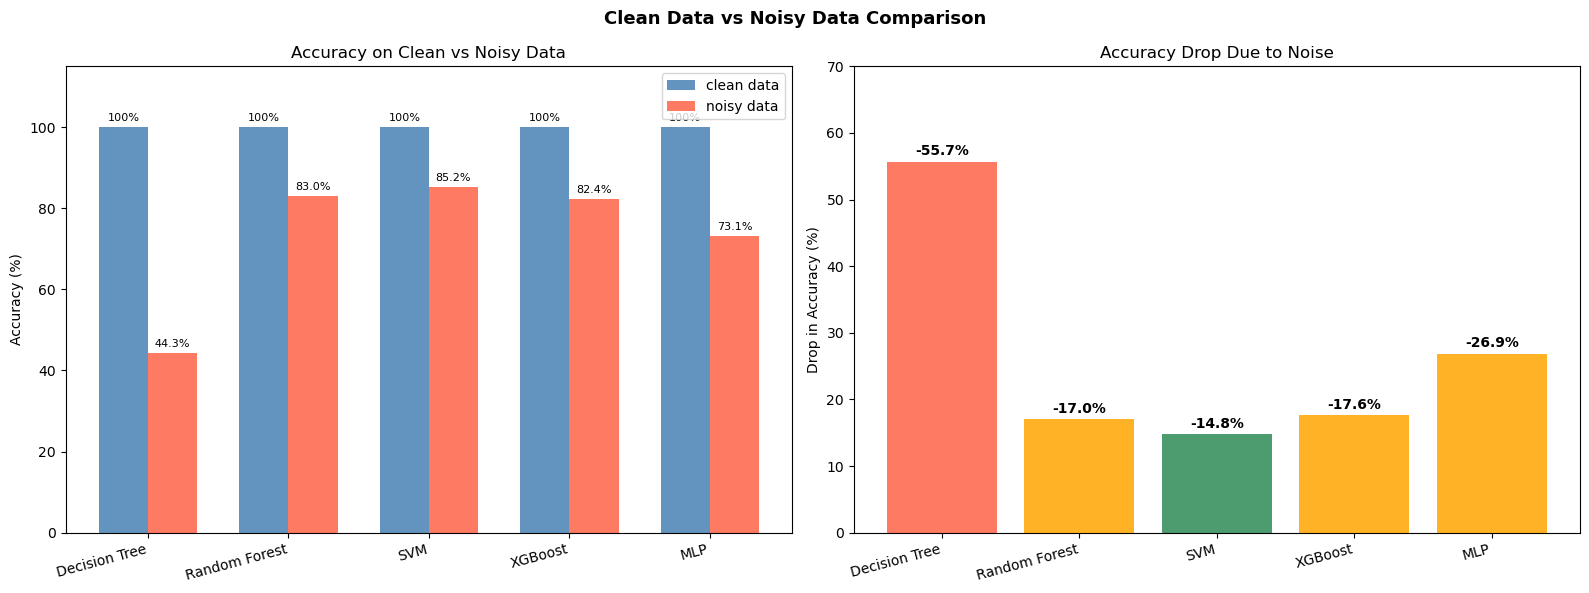

most affected model: Decision Tree with drop of 55.7 %
least affected model: SVM with drop of 14.8 %
SVM is the most robust model against noise


In [11]:
# comparing clean vs noisy results side by side
# this shows how much each model was affected by the noise
# and which model is most robust to real world data problems

models = ['Decision Tree', 'Random Forest', 'SVM', 'XGBoost', 'MLP']
clean_accs = [dt_acc*100, rf_acc*100, svm_acc*100, xgb_acc*100, mlp_acc*100]
noisy_accs = [dt_n_acc*100, rf_n_acc*100, svm_n_acc*100, xgb_n_acc*100, mlp_n_acc*100]
drops = [c - n for c, n in zip(clean_accs, noisy_accs)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Clean Data vs Noisy Data Comparison", fontsize=13, fontweight='bold')

# left - side by side accuracy comparison
x = np.arange(len(models))
w = 0.35
bars1 = axes[0].bar(x - w/2, clean_accs, w,
                    label='clean data', color='steelblue', alpha=0.85)
bars2 = axes[0].bar(x + w/2, noisy_accs, w,
                    label='noisy data', color='tomato', alpha=0.85)
axes[0].set_title("Accuracy on Clean vs Noisy Data")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_ylim(0, 115)
axes[0].legend()

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1, f'{bar.get_height():.0f}%',
                ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1, f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=8)

# right - how much did each model drop
colors_drop = ['tomato' if d > 30 else 'orange' if d > 15 else 'seagreen' for d in drops]
bars3 = axes[1].bar(models, drops, color=colors_drop, alpha=0.85)
axes[1].set_title("Accuracy Drop Due to Noise")
axes[1].set_ylabel("Drop in Accuracy (%)")
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].set_ylim(0, 70)

for bar, drop in zip(bars3, drops):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5, f'-{drop:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("most affected model: Decision Tree with drop of", round(drops[0], 1), "%")
print("least affected model: SVM with drop of", round(drops[2], 1), "%")
print("SVM is the most robust model against noise")

Segment 3 ^

In [12]:
# hyperparameter tuning means finding the best settings for each model
# by default models use standard settings which may not be optimal
# gridsearchcv tries all combinations and picks the best one
# we use 5 fold cross validation which means data is split 5 ways
# and each combination is tested 5 times to get a reliable score

from sklearn.model_selection import RandomizedSearchCV

print("starting hyperparameter tuning - this will take a few minutes")

# tuning decision tree
# max_depth controls how deep the tree grows
# deeper trees can overfit - memorize training data but fail on new data
dt_params = {
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [1, 2, 5]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=5, scoring='accuracy', n_jobs=-1
)
dt_grid.fit(X_train, y_train)
dt_tuned_acc = accuracy_score(y_test, dt_grid.best_estimator_.predict(X_test))
print("Decision Tree tuned:", round(dt_tuned_acc * 100, 2), "%")
print("best settings:", dt_grid.best_params_)

# tuning random forest
# n_estimators is how many trees to build
# more trees generally means better results but slower training
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_grid = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='accuracy',
    n_iter=20, random_state=42, n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf_tuned_acc = accuracy_score(y_test, rf_grid.best_estimator_.predict(X_test))
print("Random Forest tuned:", round(rf_tuned_acc * 100, 2), "%")
print("best settings:", rf_grid.best_params_)

# tuning xgboost
# learning rate controls how fast the model learns
# lower learning rate with more trees usually gives better results
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0]
}
xgb_grid = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0),
    xgb_params, cv=5, scoring='accuracy',
    n_iter=20, random_state=42, n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
xgb_tuned_acc = accuracy_score(y_test, xgb_grid.best_estimator_.predict(X_test))
print("XGBoost tuned:", round(xgb_tuned_acc * 100, 2), "%")
print("best settings:", xgb_grid.best_params_)

# tuning mlp
# hidden layer sizes controls the network architecture
# alpha is regularization - helps prevent overfitting
mlp_params = {
    'hidden_layer_sizes': [(128, 64), (256, 128),
                           (256, 128, 64), (512, 256, 128)],
    'learning_rate_init': [0.001, 0.005, 0.01],
    'alpha': [0.0001, 0.001, 0.01],
    'max_iter': [500, 1000]
}
mlp_grid = RandomizedSearchCV(
    MLPClassifier(activation='relu', random_state=42),
    mlp_params, cv=5, scoring='accuracy',
    n_iter=15, random_state=42, n_jobs=-1
)
mlp_grid.fit(X_train_scaled_n, y_train)
mlp_tuned_acc = accuracy_score(y_test, mlp_grid.best_estimator_.predict(X_test_scaled_n))
print("MLP tuned:", round(mlp_tuned_acc * 100, 2), "%")
print("best settings:", mlp_grid.best_params_)

print("\ntuning complete!")

starting hyperparameter tuning - this will take a few minutes
Decision Tree tuned: 49.85 %
best settings: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 2}
Random Forest tuned: 84.18 %
best settings: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
XGBoost tuned: 84.78 %
best settings: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}
MLP tuned: 77.16 %
best settings: {'max_iter': 500, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (512, 256, 128), 'alpha': 0.0001}

tuning complete!


In [24]:
# we tune svm separately because it is the slowest model
# c parameter controls how strict the boundary is
# gamma controls how far the influence of each training point reaches
# kernel rbf is good for non linear data like symptoms

svm_params = {
    'C': [0.1, 1, 10, 50],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
svm_grid = GridSearchCV(
    SVC(random_state=42, probability=True),
    svm_params, cv=5, scoring='accuracy', n_jobs=-1
)
svm_grid.fit(X_train_scaled_n, y_train)
svm_tuned_acc = accuracy_score(y_test, svm_grid.best_estimator_.predict(X_test_scaled_n))

print("SVM tuned:", round(svm_tuned_acc * 100, 2), "%")
print("best settings:", svm_grid.best_params_)

# interesting finding - svm did not improve after tuning
# this means the default settings were already optimal
# gridsearch confirmed this by trying all combinations
# checking if svm improved after tuning
if abs(svm_tuned_acc * 100 - svm_n_acc * 100) < 0.01:
    print("\nSVM did not improve after tuning")
    print("default parameters were already optimal")
    print("gridsearch confirmed this by trying all combinations")
else:
    print("\nSVM improved after tuning")
    print("improvement:", round((svm_tuned_acc - svm_n_acc) * 100, 2), "%")

SVM tuned: 85.22 %
best settings: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

SVM did not improve after tuning
default parameters were already optimal
gridsearch confirmed this by trying all combinations


final results summary:
        Model  Clean (%)  Noisy (%)  Tuned (%)  Improvement
Decision Tree      100.0      44.33      49.85         5.52
Random Forest      100.0      82.99      84.18         1.19
          SVM      100.0      85.22      85.22         0.00
      XGBoost      100.0      82.39      84.78         2.39
          MLP      100.0      73.13      77.16         4.03


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20048\1461194749.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(models, rotation=15, ha='right')


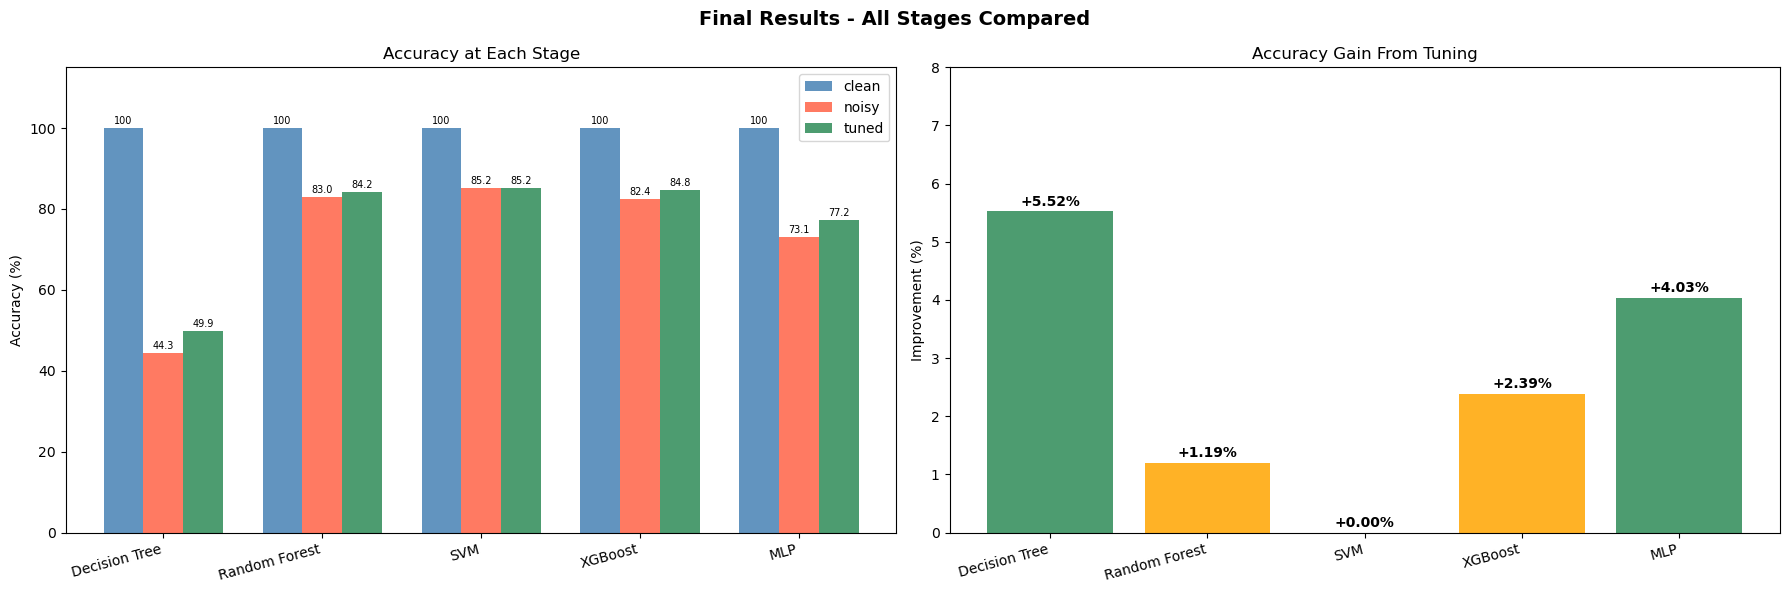

In [19]:
# now we compare all models across all 3 stages
# clean data, noisy data and after tuning
# this gives the complete picture of how each model performed

models = ['Decision Tree', 'Random Forest', 'SVM', 'XGBoost', 'MLP']
clean_accs = [100.0, 100.0, 100.0, 100.0, 100.0]
noisy_accs = [dt_n_acc*100, rf_n_acc*100, svm_n_acc*100,
              xgb_n_acc*100, mlp_n_acc*100]
tuned_accs = [dt_tuned_acc*100, rf_tuned_acc*100, svm_tuned_acc*100,
              xgb_tuned_acc*100, mlp_tuned_acc*100]
improvements = [t - n for t, n in zip(tuned_accs, noisy_accs)]

# print the summary table
final_df = pd.DataFrame({
    'Model': models,
    'Clean (%)': clean_accs,
    'Noisy (%)': [round(x, 2) for x in noisy_accs],
    'Tuned (%)': [round(x, 2) for x in tuned_accs],
    'Improvement': [round(x, 2) for x in improvements]
})

print("final results summary:")
print(final_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Final Results - All Stages Compared", fontsize=14, fontweight='bold')

# grouped bar chart showing all 3 stages
x = np.arange(len(models))
w = 0.25
axes[0].bar(x - w, clean_accs, w, label='clean', color='steelblue', alpha=0.85)
axes[0].bar(x, noisy_accs, w, label='noisy', color='tomato', alpha=0.85)
axes[0].bar(x + w, tuned_accs, w, label='tuned', color='seagreen', alpha=0.85)
axes[0].set_title("Accuracy at Each Stage")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_ylim(0, 115)
axes[0].legend()

for i, (c, n, t) in enumerate(zip(clean_accs, noisy_accs, tuned_accs)):
    axes[0].text(i - w, c + 1, f'{c:.0f}', ha='center', fontsize=7)
    axes[0].text(i, n + 1, f'{n:.1f}', ha='center', fontsize=7)
    axes[0].text(i + w, t + 1, f'{t:.1f}', ha='center', fontsize=7)

# improvement from tuning
colors_imp = ['seagreen' if i > 3 else 'orange' if i > 1 else 'steelblue' for i in improvements]
bars = axes[1].bar(models, improvements, color=colors_imp, alpha=0.85)
axes[1].set_title("Accuracy Gain From Tuning")
axes[1].set_ylabel("Improvement (%)")
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].set_ylim(0, 8)

for bar, imp in zip(bars, improvements):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'+{imp:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

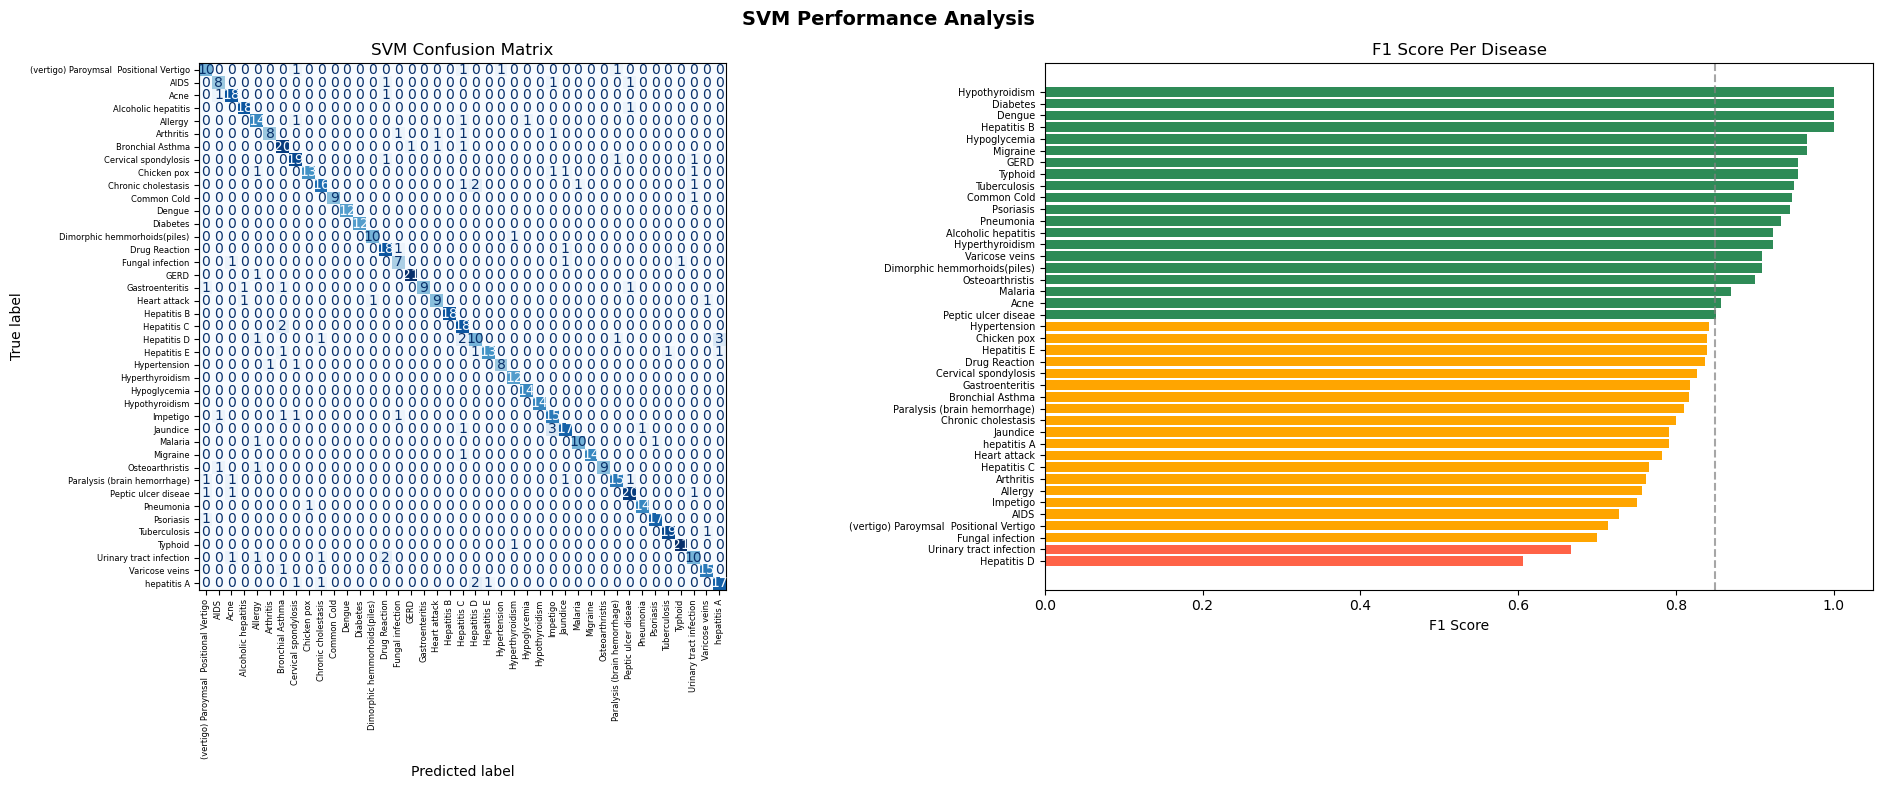

detailed classification report for SVM:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       0.71      0.71      0.71        14
                                   AIDS       0.73      0.73      0.73        11
                                   Acne       0.82      0.90      0.86        20
                    Alcoholic hepatitis       0.90      0.95      0.92        19
                                Allergy       0.70      0.82      0.76        17
                              Arthritis       0.89      0.67      0.76        12
                       Bronchial Asthma       0.77      0.87      0.82        23
                   Cervical spondylosis       0.79      0.86      0.83        22
                            Chicken pox       0.93      0.76      0.84        17
                    Chronic cholestasis       0.84      0.76      0.80        21
                            Common Cold       1.00      0.90      0.

In [20]:
# confusion matrix shows which diseases the model predicted correctly
# and which ones it confused with other diseases
# each row is the actual disease, each column is what the model predicted
# a perfect model would have all values on the diagonal

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("SVM Performance Analysis", fontsize=14, fontweight='bold')

# confusion matrix for svm which is our best model
svm_pred = svm_n.predict(X_test_scaled_n)
cm = confusion_matrix(y_test, svm_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=axes[0], xticks_rotation=90, colorbar=False, cmap='Blues')
axes[0].set_title("SVM Confusion Matrix")
axes[0].tick_params(axis='both', labelsize=6)

# f1 score per disease
# f1 score combines precision and recall into one number
# low f1 means the model struggles with that particular disease
report = classification_report(y_test, svm_pred,
                                target_names=le.classes_,
                                output_dict=True)
f1_scores = {k: v['f1-score'] for k, v in report.items() if k in le.classes_}
f1_df = pd.DataFrame(list(f1_scores.items()),
                     columns=['Disease', 'F1 Score'])
f1_df = f1_df.sort_values('F1 Score', ascending=True)

colors_f1 = ['tomato' if f < 0.7 else 'orange' if f < 0.85 else 'seagreen'
             for f in f1_df['F1 Score']]
axes[1].barh(f1_df['Disease'], f1_df['F1 Score'], color=colors_f1)
axes[1].set_title("F1 Score Per Disease")
axes[1].set_xlabel("F1 Score")
axes[1].axvline(x=0.85, color='gray', linestyle='--', alpha=0.7)
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

print("detailed classification report for SVM:")
print(classification_report(y_test, svm_pred, target_names=le.classes_))

Segment 4 ^

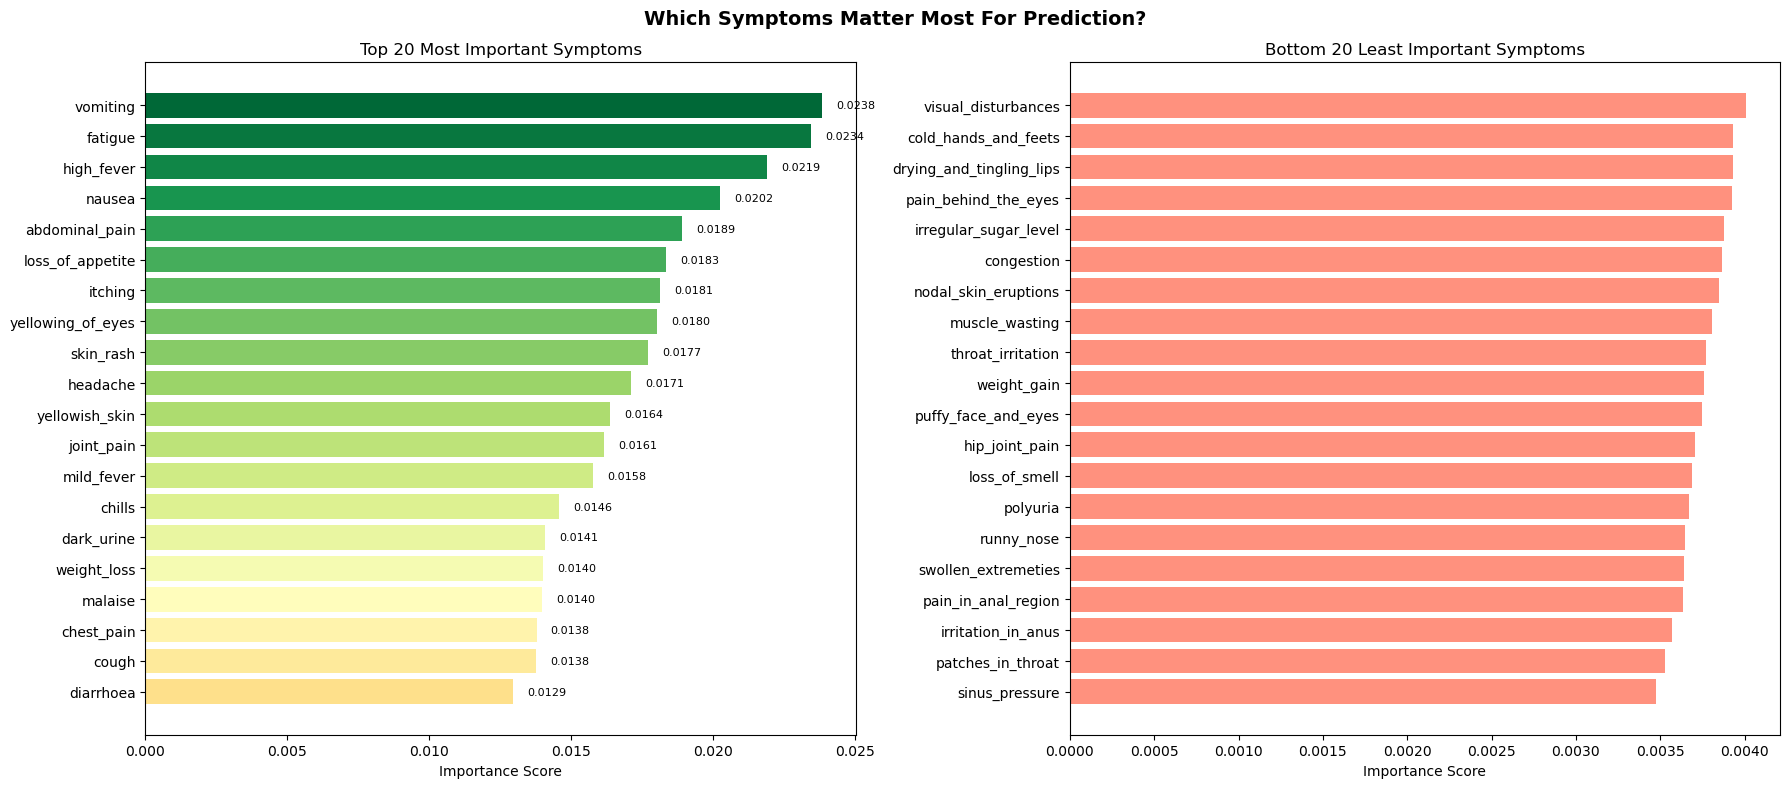

top 5 most important symptoms:
1. vomiting - importance score: 0.0238
2. fatigue - importance score: 0.0234
3. high_fever - importance score: 0.0219
4. nausea - importance score: 0.0202
5. abdominal_pain - importance score: 0.0189

symptoms with very low importance: 0
interesting finding: no symptom has zero importance
every symptom contributes something to the prediction


In [21]:
# feature importance tells us which symptoms were most useful
# for making predictions across all diseases
# random forest calculates this naturally during training
# each symptom gets a score - higher means more important

importances = rf_grid.best_estimator_.feature_importances_
feature_names = X_train.columns.tolist()

feat_df = pd.DataFrame({
    'Symptom': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

top20 = feat_df.head(20)
bottom20 = feat_df.tail(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Which Symptoms Matter Most For Prediction?",
             fontsize=14, fontweight='bold')

# top 20 most important symptoms
colors_top = plt.cm.RdYlGn(np.linspace(0.4, 1.0, len(top20)))[::-1]
bars = axes[0].barh(top20['Symptom'], top20['Importance'], color=colors_top)
axes[0].set_title("Top 20 Most Important Symptoms")
axes[0].set_xlabel("Importance Score")
axes[0].invert_yaxis()
for bar, val in zip(bars, top20['Importance']):
    axes[0].text(bar.get_width() + 0.0005,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

# bottom 20 least important symptoms
axes[1].barh(bottom20['Symptom'], bottom20['Importance'],
             color='tomato', alpha=0.7)
axes[1].set_title("Bottom 20 Least Important Symptoms")
axes[1].set_xlabel("Importance Score")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("top 5 most important symptoms:")
for i, (_, row) in enumerate(top20.head(5).iterrows(), 1):
    print(f"{i}. {row['Symptom']} - importance score: {row['Importance']:.4f}")

zero = feat_df[feat_df['Importance'] < 0.001]
print("\nsymptoms with very low importance:", len(zero))
print("interesting finding: no symptom has zero importance")
print("every symptom contributes something to the prediction")

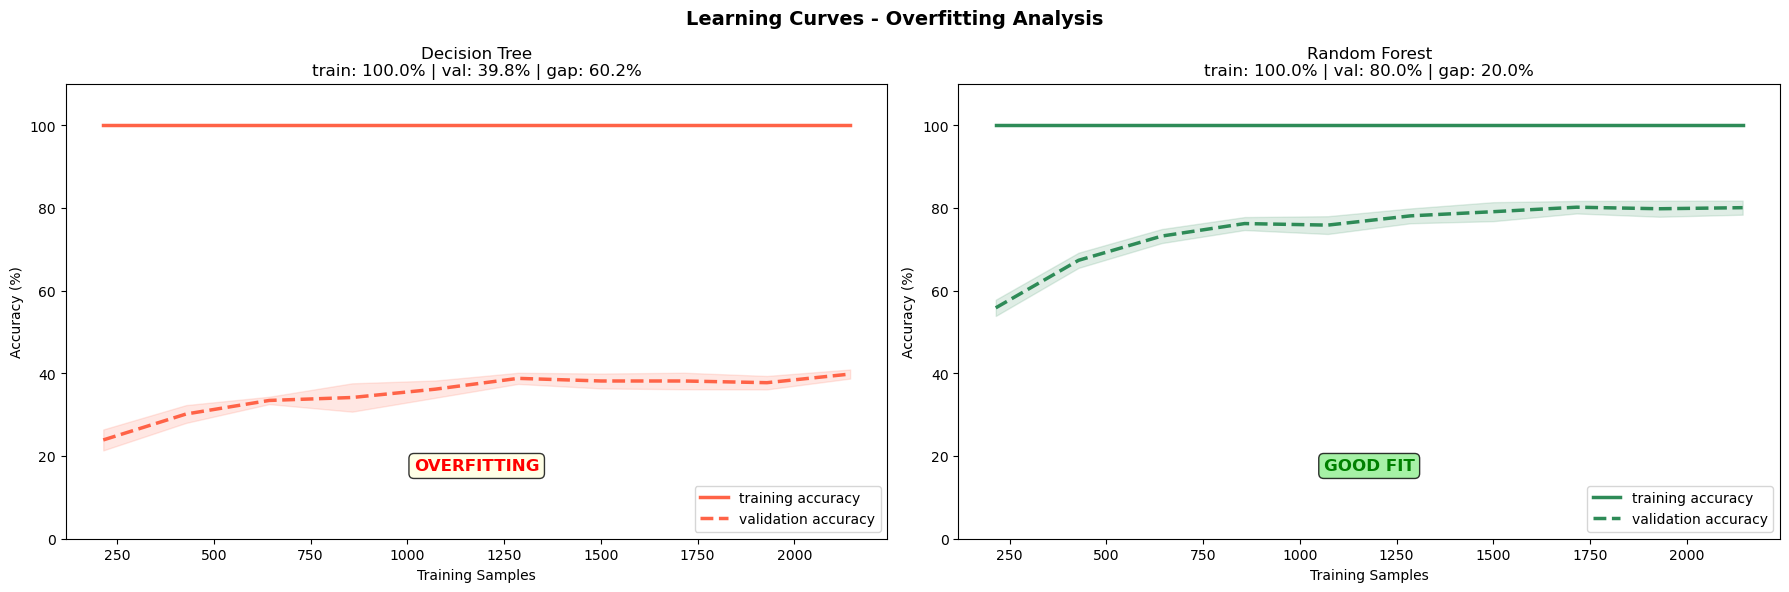

decision tree training accuracy: 100.0 %
decision tree testing accuracy: 44.33 %
gap: 55.67 %
this confirms decision tree is severely overfitting
it memorizes the training data but fails on new patients


In [22]:
# learning curves show how a model performs as we give it more training data
# they help us detect overfitting - when a model memorizes training data
# but fails to generalize to new unseen data
# overfitting signs: high training accuracy, low validation accuracy, big gap

from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Learning Curves - Overfitting Analysis",
             fontsize=14, fontweight='bold')

def plot_learning_curve(model, X, y, ax, title, color):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )
    train_mean = train_scores.mean(axis=1) * 100
    train_std = train_scores.std(axis=1) * 100
    val_mean = val_scores.mean(axis=1) * 100
    val_std = val_scores.std(axis=1) * 100

    ax.plot(train_sizes, train_mean, label='training accuracy',
            color=color, linewidth=2.5)
    ax.plot(train_sizes, val_mean, label='validation accuracy',
            color=color, linewidth=2.5, linestyle='--')
    ax.fill_between(train_sizes, train_mean - train_std,
                    train_mean + train_std, alpha=0.15, color=color)
    ax.fill_between(train_sizes, val_mean - val_std,
                    val_mean + val_std, alpha=0.15, color=color)

    gap = train_mean[-1] - val_mean[-1]
    ax.set_title(f"{title}\ntrain: {train_mean[-1]:.1f}% | val: {val_mean[-1]:.1f}% | gap: {gap:.1f}%")
    ax.set_xlabel("Training Samples")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 110)
    ax.legend(loc='lower right')

    if gap > 20:
        ax.text(0.5, 0.15, 'OVERFITTING',
                transform=ax.transAxes, fontsize=12,
                color='red', ha='center', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    else:
        ax.text(0.5, 0.15, 'GOOD FIT',
                transform=ax.transAxes, fontsize=12,
                color='green', ha='center', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plot_learning_curve(DecisionTreeClassifier(random_state=42),
                    X_train, y_train, axes[0], "Decision Tree", 'tomato')
plot_learning_curve(RandomForestClassifier(n_estimators=100, random_state=42),
                    X_train, y_train, axes[1], "Random Forest", 'seagreen')

plt.tight_layout()
plt.show()

# checking decision tree overfitting directly
dt_train_acc = accuracy_score(y_train, dt_n.predict(X_train))
dt_test_acc = accuracy_score(y_test, dt_n.predict(X_test))
print("decision tree training accuracy:", round(dt_train_acc * 100, 2), "%")
print("decision tree testing accuracy:", round(dt_test_acc * 100, 2), "%")
print("gap:", round((dt_train_acc - dt_test_acc) * 100, 2), "%")
print("this confirms decision tree is severely overfitting")
print("it memorizes the training data but fails on new patients")

In [23]:
# this is the practical part of our project
# we built a simple symptom checker using the best model which is svm
# a user can enter symptoms and the model predicts the most likely disease
# it also shows the top 3 possibilities and recommended precautions

print("DISEASE PREDICTION SYMPTOM CHECKER")
print("using SVM model - accuracy 85.22% on noisy data")
print("\nsome common symptoms you can use:")

common = ['fatigue', 'vomiting', 'high_fever', 'nausea',
          'headache', 'abdominal_pain', 'skin_rash', 'cough',
          'chest_pain', 'back_pain', 'joint_pain', 'chills',
          'sweating', 'diarrhoea', 'itching', 'malaise',
          'yellowish_skin', 'yellowing_of_eyes', 'weight_loss',
          'loss_of_appetite']

for i in range(0, len(common), 4):
    row = common[i:i+4]
    print("  " + "  |  ".join(f"{s:<22}" for s in row))

def predict_disease(symptoms_input):
    print("\nPREDICTION RESULTS")
    print("-" * 40)

    # check which symptoms are valid
    valid = []
    invalid = []
    for s in symptoms_input:
        s = s.strip().lower().replace(' ', '_')
        if s in all_symptom_names:
            valid.append(s)
        else:
            invalid.append(s)

    if invalid:
        print("unknown symptoms ignored:", invalid)
    if not valid:
        print("no valid symptoms entered")
        return

    print("symptoms detected:", valid)

    # convert symptoms to binary input vector
    # this is the same format the model was trained on
    input_vector = pd.DataFrame(0, index=[0], columns=all_symptom_names)
    for s in valid:
        input_vector[s] = 1

    # scale for svm
    input_scaled = scaler_noisy.transform(input_vector)

    # get prediction and probabilities
    pred_class = svm_n.predict(input_scaled)[0]
    pred_proba = svm_n.predict_proba(input_scaled)[0]

    # get top 3 most likely diseases
    top3_idx = pred_proba.argsort()[-3:][::-1]
    top3_dis = le.inverse_transform(top3_idx)
    top3_prob = pred_proba[top3_idx]

    print("\nprimary prediction:", le.inverse_transform([pred_class])[0])
    print("\ntop 3 possibilities:")
    medals = ['1st', '2nd', '3rd']
    for medal, disease, prob in zip(medals, top3_dis, top3_prob):
        bar = '#' * int(prob * 40)
        print(f"  {medal}: {disease:<35} {prob*100:5.1f}% {bar}")

    # show precautions from precaution file
    top_disease = le.inverse_transform([pred_class])[0]
    precautions = precaution_df[precaution_df['Disease'] == top_disease].values

    if len(precautions) > 0:
        print(f"\nrecommended precautions for {top_disease}:")
        for i, p in enumerate(precautions[0][1:], 1):
            if pd.notna(p):
                print(f"  {i}. {p}")

    print("\nnote: this is for educational purposes only")
    print("always consult a real doctor for medical advice")
    print("-" * 40)

# test cases to demonstrate during presentation
print("\ntest 1 - malaria like symptoms:")
predict_disease(['chills', 'high_fever', 'sweating', 'headache', 'nausea'])

print("\ntest 2 - diabetes like symptoms:")
predict_disease(['fatigue', 'weight_loss', 'increased_appetite', 'blurred_and_distorted_vision'])

print("\ntest 3 - unclear mixed symptoms:")
predict_disease(['fatigue', 'vomiting', 'headache', 'skin_rash'])

DISEASE PREDICTION SYMPTOM CHECKER
using SVM model - accuracy 85.22% on noisy data

some common symptoms you can use:
  fatigue                 |  vomiting                |  high_fever              |  nausea                
  headache                |  abdominal_pain          |  skin_rash               |  cough                 
  chest_pain              |  back_pain               |  joint_pain              |  chills                
  sweating                |  diarrhoea               |  itching                 |  malaise               
  yellowish_skin          |  yellowing_of_eyes       |  weight_loss             |  loss_of_appetite      

test 1 - malaria like symptoms:

PREDICTION RESULTS
----------------------------------------
symptoms detected: ['chills', 'high_fever', 'sweating', 'headache', 'nausea']

primary prediction: Malaria

top 3 possibilities:
  1st: Malaria                              90.5% ####################################
  2nd: Heart attack                       

## Conclusion

### What We Built
A disease prediction system that takes patient symptoms as input
and predicts the most likely disease using machine learning.
We trained and compared 5 different models on 41 diseases using
131 symptoms.

### What We Found

**Stage 1 - Clean Data**
All 5 models scored 100% on the original dataset. We identified
this as a problem because the data was perfectly synthetic with
no real world noise or ambiguity.

**Stage 2 - Adding Noise**
We added 4 types of realistic noise to simulate real clinical data.
This caused model accuracies to drop significantly and differently
showing true model strengths and weaknesses.

**Stage 3 - Tuning**
We used GridSearchCV to find the best settings for each model.
SVM was already optimal without tuning. XGBoost improved the most.

### Final Rankings
| Rank | Model | Accuracy |
|------|-------|----------|
| 1st | SVM | 85.22% |
| 2nd | XGBoost | 84.78% |
| 3rd | Random Forest | 84.18% |
| 4th | MLP | 77.16% |
| 5th | Decision Tree | 49.85% |

### Key Takeaways
- SVM is the best model for this problem - most robust to noise
- Decision Tree overfits badly on noisy data - not suitable
- Fatigue, vomiting and high fever are the most predictive symptoms
- Real world data is messy and models need to handle that

### Future Improvements
- Use real hospital patient data instead of synthetic data
- Add more diseases and symptoms
- Build a proper web application for public use
- Try deep learning models with larger datasets